# Notebook 4 - Vegetation greenness: recovery in the 2025/26 wet season?

<a target="_blank" href="https://colab.research.google.com/github/khouakhi/UMP_EO_training/blob/main/notebooks/04_vegetation_ndvi_recovery.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


## Concept

**NDVI** (Normalised Difference Vegetation Index) from [**Sentinel-2 SR Harmonized**](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED) uses **red** and **near-infrared** reflectance. Healthy **green leaves** have **high NDVI**; **bare soil** and **urban** surfaces are lower.

## Research questions

1. Which areas had **lower NDVI in the wet season ending April 2025** (drier / less green)?
2. Where is **ΔNDVI** (wet season **2025/26** minus **2024/25**) largest (strongest green-up)?
3. Does the spatial pattern **look similar** to the rainfall and water maps from earlier notebooks?

## Output

- Median **NDVI** maps for wet seasons **2024/25** and **2025/26** (compute medians in one cell, map in the next).
- A **difference map**, then a **sampled scatter** (Apr26 vs Apr25) **in addition to** a **histogram** of ΔNDVI (run the scatter cell first so both use the same `df_ndvi`).

**Time tip:** about **30 minutes**.


In [1]:
# Install packages (Colab often needs a fresh install each session)
!pip install -q earthengine-api geemap

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# If you run this notebook locally, run `ee.Authenticate()` once before `ee.Initialize`.
# If the Colab pop-up fails, try: ee.Authenticate(auth_mode="colab")
# Mapping notebooks use `Map.add_basemap("SATELLITE")` so you always have photo context under EE layers.


In [ ]:
# Connect to Google Earth Engine using your cloud project ID.
# Set this to your own Google Earth Engine cloud project ID before running.
EE_PROJECT = "YOUR_GEE_PROJECT_ID"
# EE_PROJECT = "ee-gee-hydro"

try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)

print("Earth Engine initialised with project:", EE_PROJECT)


Earth Engine initialised with project: ee-gee-hydro


In [4]:
# Study area: Moulouya basin - HydroSHEDS level-8 hydrological unit (WWF)
# Dataset: WWF/HydroSHEDS/v1/Basins/hybas_8 - use the same HYBAS_ID in every notebook for consistency.

HYBAS_ID = 1080030220

MOULOUYA_BASIN_H08 = ee.FeatureCollection("WWF/HydroSHEDS/v1/Basins/hybas_8").filter(
    ee.Filter.eq("HYBAS_ID", HYBAS_ID)
)

# Geometry used for clips, filterBounds, reduceRegion, etc.
LOWER_MOULOUYA_AOI = MOULOUYA_BASIN_H08.geometry()

# Extended winter–spring wet season (December–April), named by the April that closes the window.


def wet_season_filter_dates(april_year: int) -> tuple[str, str]:
    # Returns filterDate(start, end) with end exclusive; April is fully included.
    start = f"{april_year - 1}-12-01"
    end = f"{april_year}-05-01"
    return (start, end)


In [5]:
SCALE = 1 / 10_000


def add_ndvi(img: ee.Image) -> ee.Image:
    nir = img.select("B8").multiply(SCALE)
    red = img.select("B4").multiply(SCALE)
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    return img.addBands(ndvi)


def s2_wet_season_ndvi_median(april_year: int) -> ee.Image:
    start, end = wet_season_filter_dates(april_year)
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(LOWER_MOULOUYA_AOI)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 70))
        .map(add_ndvi)
    )
    return s2.median().clip(LOWER_MOULOUYA_AOI).select("NDVI")


ndvi_apr2025 = s2_wet_season_ndvi_median(2025)
ndvi_apr2026 = s2_wet_season_ndvi_median(2026)
dndvi = ndvi_apr2026.subtract(ndvi_apr2025).rename("dNDVI")


In [ ]:
visv = {"min": 0.0, "max": 0.85, "palette": ["#ffffcc", "#78c679", "#006837"]}
aoi_vis = {"color": "red"}

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(LOWER_MOULOUYA_AOI, 9)
Map.addLayer(ndvi_apr2025, visv, "NDVI Apr25")
Map.addLayer(ndvi_apr2026, visv, "NDVI Apr26")
Map.addLayer(LOWER_MOULOUYA_AOI, aoi_vis, "AOI", opacity=0.2)
Map


## Difference map


In [7]:
dndvi_vis = {"min": -0.35, "max": 0.35, "palette": ["d73027", "ffffbf", "1a9850"]}
aoi_vis = {"color": "333333"}

Map2 = geemap.Map()
Map2.add_basemap("SATELLITE")
Map2.centerObject(LOWER_MOULOUYA_AOI, 9)
Map2.addLayer(dndvi, dndvi_vis, "dNDVI")
Map2.addLayer(LOWER_MOULOUYA_AOI, aoi_vis, "AOI", opacity=0.2)
Map2


Map(center=[34.88374700771184, -2.5725774983515297], controls=(WidgetControl(options=['position', 'transparent…

## Scatter - Apr26 vs Apr25 (sampled)

**2500** pixels, **`scale=100` m**, **`seed=42`**. **Above** the dashed **y = x** line -> higher NDVI in **Apr26**; **below** -> lower. Point **colour** is **ΔNDVI** (same scale idea as the map).


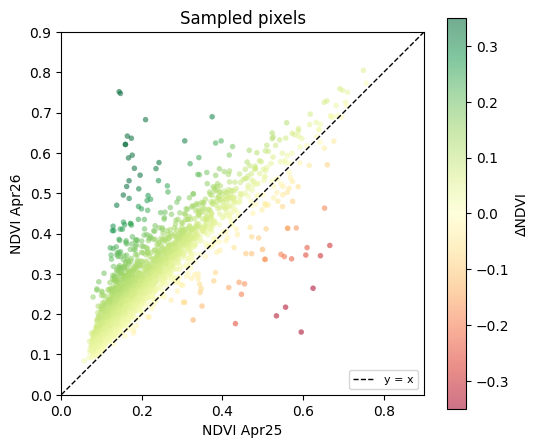

In [8]:
ndvi_pair = (
    ndvi_apr2025.rename("NDVI_Apr25")
    .addBands(ndvi_apr2026.rename("NDVI_Apr26"))
    .addBands(dndvi)
)
pts_fc = ndvi_pair.sample(
    region=LOWER_MOULOUYA_AOI,
    scale=100,
    numPixels=2500,
    geometries=False,
    seed=42,
)
df_ndvi = geemap.ee_to_df(pts_fc)

import numpy as np

x = df_ndvi["NDVI_Apr25"].to_numpy(dtype=float)
y = df_ndvi["NDVI_Apr26"].to_numpy(dtype=float)
dz = df_ndvi["dNDVI"].to_numpy(dtype=float)
ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(dz)
x, y, dz = x[ok], y[ok], dz[ok]

fig, ax = plt.subplots(figsize=(5.5, 5.2))
lim = (0.0, 0.9)
ax.plot(lim, lim, "k--", linewidth=1.0, label="y = x")
sc = ax.scatter(
    x,
    y,
    c=dz,
    cmap="RdYlGn",
    vmin=-0.35,
    vmax=0.35,
    s=16,
    alpha=0.55,
    edgecolors="none",
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("NDVI Apr25")
ax.set_ylabel("NDVI Apr26")
ax.set_title("Sampled pixels")
ax.legend(loc="lower right", fontsize=8)
fig.colorbar(sc, ax=ax, shrink=0.82, label="ΔNDVI")
plt.tight_layout()
plt.show()


## Histogram - ΔNDVI (same sample)

Uses **`df_ndvi`** from the **scatter cell** (run that cell first).


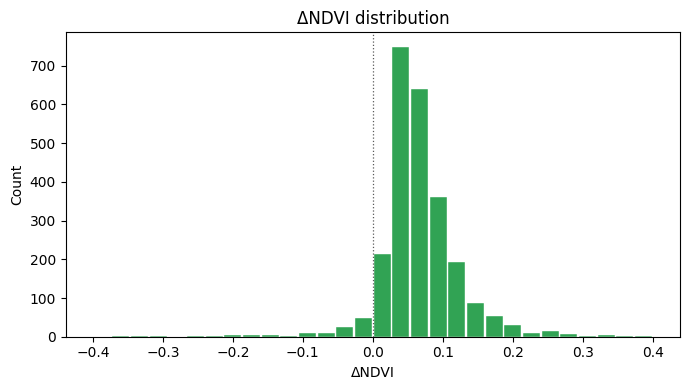

In [9]:
import numpy as np

if "df_ndvi" not in globals():
    raise RuntimeError("Run the scatter cell above first (it builds df_ndvi).")

dz = df_ndvi["dNDVI"].to_numpy(dtype=float)
dz = dz[np.isfinite(dz)]

dz_lo, dz_hi, n_bins = -0.4, 0.4, 30
counts, edges = np.histogram(dz, bins=n_bins, range=(dz_lo, dz_hi))
centres = (edges[:-1] + edges[1:]) / 2.0
bin_w = (dz_hi - dz_lo) / n_bins

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(centres, counts, width=bin_w * 0.92, color="#31a354", edgecolor="white", linewidth=0.3)
ax.axvline(0.0, color="0.35", linestyle=":", linewidth=0.9)
ax.set_xlabel("ΔNDVI")
ax.set_ylabel("Count")
ax.set_title("ΔNDVI distribution")
plt.tight_layout()
plt.show()


## Optional extension - EVI

EVI is less saturated than NDVI in **dense** vegetation. If you finish early, duplicate the NDVI function on [**Sentinel-2 SR Harmonized**](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED) using:

`EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)` with scaled reflectances.

**Next:** `06_optional_random_forest_land_cover.ipynb`.
